# fastchem cond file

In [1]:
from jax import config
config.update("jax_enable_x64", True)

We assume N2+H2O (gas, water, ice) system using fastchem/fastchem_cond presets

In [2]:
from exogibbs.presets.fastchem_cond import chemsetup as condsetup
cond = condsetup()
from exogibbs.presets.fastchem import chemsetup as gassetup
gas = gassetup()


fastchem_cond presets in ExoGibbs
number of species: 186 elements: 28 molecules: 186
fastchem presets in ExoGibbs
number of species: 523 elements: 28 molecules: 495


In [3]:
gas_species = list(gas.species)
gas_system = ['H2O1', 'N2']
index_h2o_gas = gas_species.index('H2O1')  
index_n2_gas = gas_species.index('N2')

cond_species = list(cond.species)
cond_system = ['H2O(s,l)']
index_h2o_cond = cond_species.index('H2O(s,l)')  

In [4]:
from exogibbs.thermo.stoichiometry import build_formula_matrix
from exogibbs.utils.nameparser import set_elements_from_components
from exogibbs.utils.nameparser import generate_components_from_formula_list

components_g = generate_components_from_formula_list(gas_system)
elements = set_elements_from_components(components_g)
formula_matrix_gas = build_formula_matrix(components_g, elements)

print("Formula matrix (gas):")
print(formula_matrix_gas)

components_c = generate_components_from_formula_list(cond_system)
formula_matrix_cond = build_formula_matrix(components_c, elements)

print("Formula matrix (cond):")
print(formula_matrix_cond)



Formula matrix (gas):
[[2 0]
 [1 0]
 [0 2]]
Formula matrix (cond):
[[2]
 [1]
 [0]]


In [18]:
def h2o_cond_h_values(T): 
    return  cond.hvector_func(T)[index_h2o_cond]

def h2o_gas_h_values(T):
    return  gas.hvector_func(T)[index_h2o_gas]

def n2_gas_h_values(T):
    return  gas.hvector_func(T)[index_n2_gas]

In [19]:
h2o_cond_h_values(300.0), h2o_gas_h_values(300.0), n2_gas_h_values(300.0), 

(Array(-350.72283839, dtype=float64),
 Array(-347.40874429, dtype=float64),
 Array(-365.19665376, dtype=float64))

In [79]:
import numpy as np
def gibbs_energy(m, n, nn2, p, T):
    ntot = n + nn2
    mu_h2o = h2o_gas_h_values(T) + np.log(p*n/ntot)
    mu_n2 = n2_gas_h_values(T) + np.log(p*nn2/ntot)
    return h2o_cond_h_values(T)*m + mu_h2o*n + mu_n2*nn2

In [123]:
nh2o = 0.1

def gibbs_given(m,T,p=1.0):
    return gibbs_energy(m, nh2o-m, 1.0 - nh2o, p, T)

In [124]:
import matplotlib.pyplot as plt

/tmp/ipykernel_676/2701145478.py:4: RuntimeWarning: divide by zero encountered in log
  mu_h2o = h2o_gas_h_values(T) + np.log(p*n/ntot)


Text(0.5, 0, 'condensate fraction')

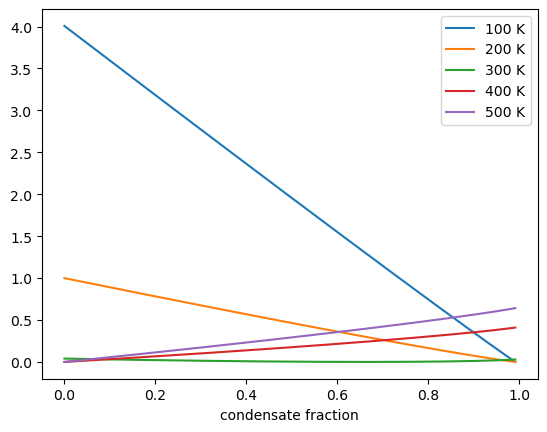

In [125]:
marr = np.logspace(-5,np.log10(nh2o),1000)
for T in [100,200,300,400,500]:
    plt.plot(marr/nh2o, gibbs_given(marr,T) - np.nanmin(gibbs_given(marr,T)), label=str(T)+" K")
plt.legend()
plt.xlabel("condensate fraction")
#plt.xscale("log")

In [126]:
def mmin(T,p=1.0):
    i = np.nanargmin(gibbs_given(marr,T,p))
    return marr[i]

In [127]:
mastarr = []
Tarr = np.linspace(100,500,50)
for T in Tarr:
    mastarr.append(mmin(T))

/tmp/ipykernel_676/2701145478.py:4: RuntimeWarning: divide by zero encountered in log
  mu_h2o = h2o_gas_h_values(T) + np.log(p*n/ntot)


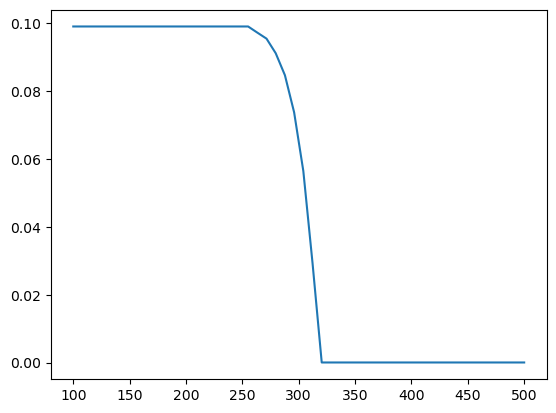

In [128]:
plt.plot(Tarr, mastarr)

In [136]:
Parr = np.logspace(-3,3,50)
Tarr = np.linspace(100,500,50)

mastarr = []
for p in Parr:
    mastarr_t = []
    for T in Tarr:
        mastarr_t.append(mmin(T,p))
    mastarr.append(mastarr_t)
mastarr = np.array(mastarr)

/tmp/ipykernel_676/2701145478.py:4: RuntimeWarning: divide by zero encountered in log
  mu_h2o = h2o_gas_h_values(T) + np.log(p*n/ntot)


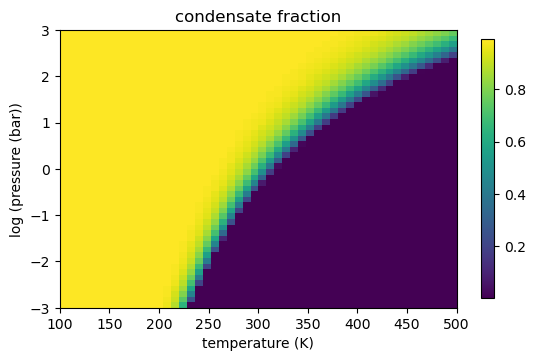

In [147]:
fig = plt.figure()
ax = fig.add_subplot(111)
c = ax.imshow(mastarr/nh2o, extent=(Tarr[0],Tarr[-1],np.log10(Parr[-1]),np.log10(Parr[0])))
plt.colorbar(c, shrink=0.7)
ax.set_aspect(0.7/ax.get_data_ratio())
plt.gca().invert_yaxis()
ax.set_xlabel("temperature (K)")
ax.set_ylabel("log (pressure (bar))")
ax.set_title("condensate fraction")
plt.show()